This section presents visualizaion for achieved results.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# load results from a file
filepath = "metrics/metrics.csv"
df = pd.read_csv(filepath)
df.head()

,source,attack,target,asr,fooling_rate,same_mistake_rate
0,VGG,FGSM,VGG,78.863534,100.0,100.0
1,VGG,PGD,VGG,97.819702,100.0,100.0
2,VGG,CW,VGG,5.693629,100.0,100.0
3,VGG,AutoAttack,VGG,44.193403,100.0,100.0
4,VGG,DeepFool,VGG,1.841392,100.0,100.0


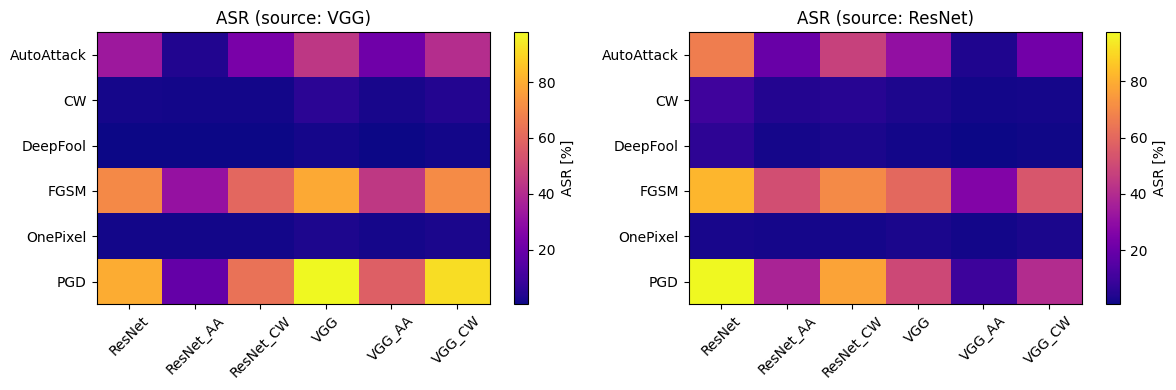

In [3]:
# heatmap of ASR for different attacks and models

df_vgg = df[df["source"] == "VGG"]
df_resnet = df[df["source"] == "ResNet"]

pivot_vgg = df_vgg.pivot_table(
    index="attack",
    columns="target",
    values="asr",
)

pivot_resnet = df_resnet.pivot_table(
    index="attack",
    columns="target",
    values="asr"
)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].imshow(pivot_vgg, aspect="auto", cmap = 'plasma')
ax[0].set_title("ASR (source: VGG)")
ax[0].set_xticks(range(len(pivot_vgg.columns)), pivot_vgg.columns, rotation=45)
ax[0].set_yticks(range(len(pivot_vgg.index)), pivot_vgg.index)

ax[1].imshow(pivot_resnet, aspect="auto", cmap = 'plasma')
ax[1].set_title("ASR (source: ResNet)")
ax[1].set_xticks(range(len(pivot_resnet.columns)), pivot_resnet.columns, rotation=45)  
ax[1].set_yticks(range(len(pivot_resnet.index)), pivot_resnet.index)

fig.colorbar(ax[1].images[0], label="ASR [%]")
fig.colorbar(ax[0].images[0], label="ASR [%]")

plt.tight_layout()
plt.show()


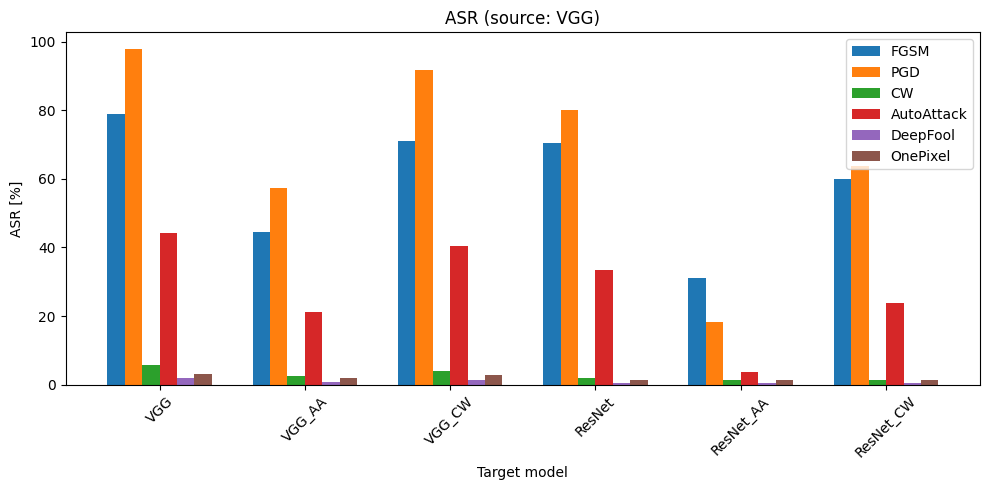

In [5]:
source_model = "VGG"
subset = df[df["source"] == source_model]

targets = subset["target"].unique()
attacks = subset["attack"].unique()

bar_width = 0.12
x = np.arange(len(targets))

plt.figure(figsize=(10, 5))

for i, attack in enumerate(attacks):
    attack_data = subset[subset["attack"] == attack]
    attack_data = attack_data.set_index("target").reindex(targets)
    plt.bar(x + i*bar_width, attack_data["asr"], width=bar_width, label=attack)

plt.xlabel("Target model")
plt.ylabel("ASR [%]")
plt.title(f"ASR (source: {source_model})")
plt.xticks(x + bar_width*(len(attacks)/2-0.5), targets, rotation=45)
# plt.ylim(88, 92)
plt.legend()
plt.tight_layout()
plt.show()


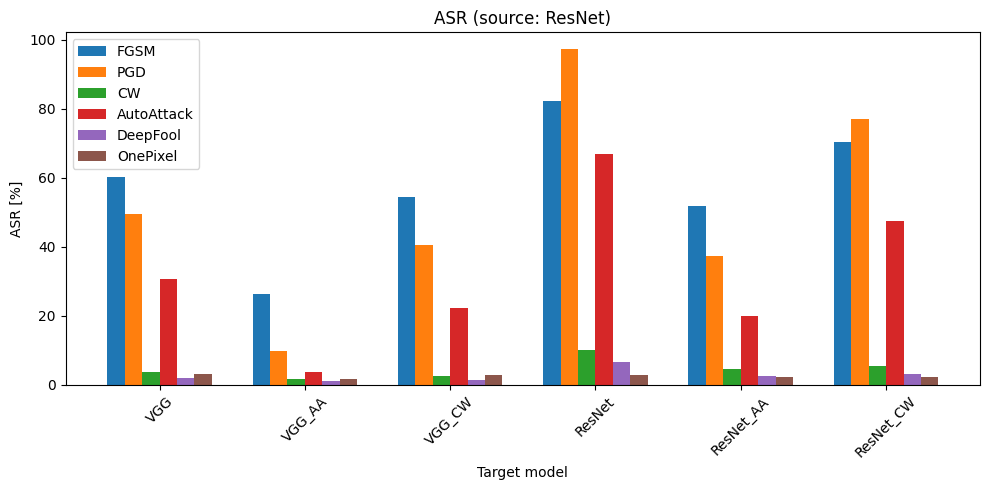

In [6]:
source_model = "ResNet"
subset = df[df["source"] == source_model]

targets = subset["target"].unique()
attacks = subset["attack"].unique()

bar_width = 0.12
x = np.arange(len(targets))

plt.figure(figsize=(10, 5))

for i, attack in enumerate(attacks):
    attack_data = subset[subset["attack"] == attack]
    attack_data = attack_data.set_index("target").reindex(targets)
    plt.bar(x + i*bar_width, attack_data["asr"], width=bar_width, label=attack)

plt.xlabel("Target model")
plt.ylabel("ASR [%]")
plt.title(f"ASR (source: {source_model})")
plt.xticks(x + bar_width*(len(attacks)/2-0.5), targets, rotation=45)
# plt.ylim(88, 92)
plt.legend()
plt.tight_layout()
plt.show()


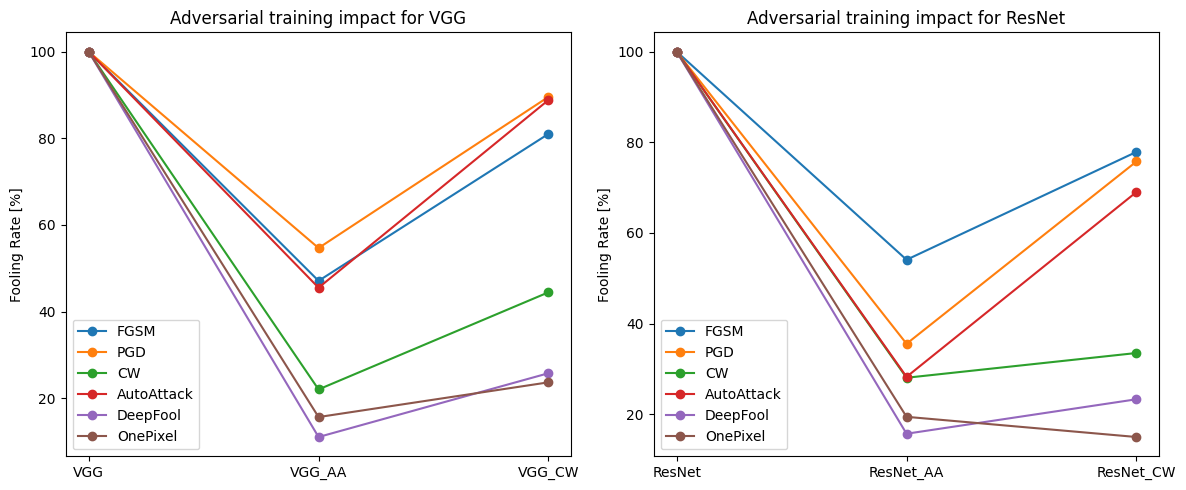

In [7]:
targets_vgg = ["VGG", "VGG_AA", "VGG_CW"]
df_vgg = df[(df["source"] == "VGG") & (df["target"].isin(targets_vgg))]

targets_resnet = ["ResNet", "ResNet_AA", "ResNet_CW"]
df_resnet = df[(df["source"] == "ResNet") & (df["target"].isin(targets_resnet))]

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

for attack in df_vgg["attack"].unique():
    vals = []
    for t in targets_vgg:
        vals.append(
            df_vgg[(df_vgg["attack"] == attack) & (df_vgg["target"] == t)]["fooling_rate"].mean()
        )
    ax[0].plot(targets_vgg, vals, marker="o", label=attack)

ax[0].set_ylabel("Fooling Rate [%]")
ax[0].set_title("Adversarial training impact for VGG")
ax[0].legend()

for attack in df_resnet["attack"].unique():
    vals = []
    for t in targets_resnet:
        vals.append(
            df_resnet[(df_resnet["attack"] == attack) & (df_resnet["target"] == t)]["fooling_rate"].mean()
        )
    ax[1].plot(targets_resnet, vals, marker="o", label=attack)

ax[1].set_ylabel("Fooling Rate [%]")
ax[1].set_title("Adversarial training impact for ResNet")
ax[1].legend()

plt.tight_layout()
plt.show()


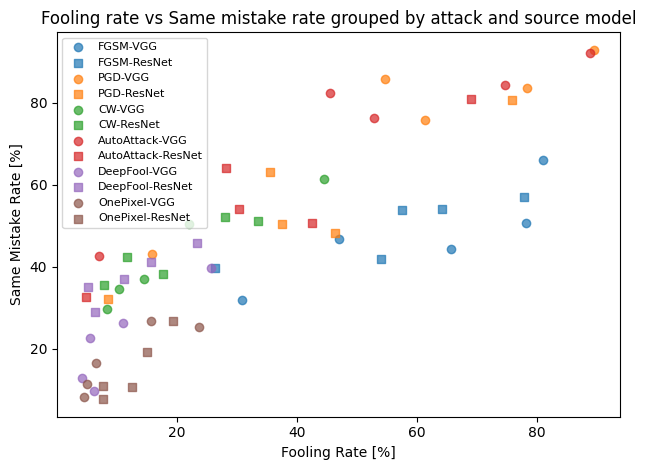

In [8]:
attacks = df["attack"].unique()
markers = {"VGG": "o", "ResNet": "s"}
attack_colors = {
    "FGSM": "tab:blue",
    "PGD": "tab:orange",
    "CW": "tab:green",
    "AutoAttack": "tab:red",
    "DeepFool": "tab:purple",
    "OnePixel": "tab:brown"
}

plt.figure()

for attack in attacks:
    subset = df[df["attack"] == attack]
    subset = subset[subset["target"] != subset["source"]]
    for src in subset["source"].unique():
        part = subset[subset["source"] == src]
        plt.scatter(
            part["fooling_rate"],
            part["same_mistake_rate"],
            color=attack_colors[attack],
            marker=markers[src],
            label=f"{attack}-{src}",
            alpha=0.7
        )

plt.xlabel("Fooling Rate [%]")
plt.ylabel("Same Mistake Rate [%]")
plt.title("Fooling rate vs Same mistake rate grouped by attack and source model")
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

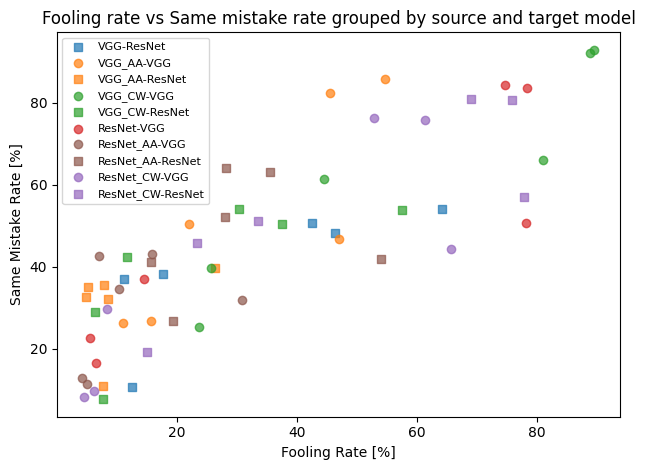

In [9]:
models = df["target"].unique()
markers = {"VGG": "o", "ResNet": "s"}
model_colors = {
    "VGG": "tab:blue",
    "VGG_AA": "tab:orange",
    "VGG_CW": "tab:green",
    "ResNet": "tab:red",
    "ResNet_CW": "tab:purple",
    "ResNet_AA": "tab:brown"
}

plt.figure()

for model in models:
    subset = df[df["target"] == model]
    subset = subset[subset["target"] != subset["source"]]
    for src in subset["source"].unique():
        part = subset[subset["source"] == src]
        plt.scatter(
            part["fooling_rate"],
            part["same_mistake_rate"],
            color=model_colors[model],
            marker=markers[src],
            label=f"{model}-{src}",
            alpha=0.7
        )

plt.xlabel("Fooling Rate [%]")
plt.ylabel("Same Mistake Rate [%]")
plt.title("Fooling rate vs Same mistake rate grouped by source and target model")
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

TO DO:
- sprawdzenie czy ataki nie są teraz za słabe
- sprawdzenie wpływu z podziałem na klasy